# MindMirror — Mental Health Text Classification

This notebook prepares the uploaded dataset for a **non-diagnostic mental-health text classification feature** in MindMirror.

Pipeline:

**Raw Kaggle dataset → data cleaning → train/validation/test split → DistilBERT fine-tuning → evaluation → export model → backend integration**

> The model output should be presented as an informational classification/risk-awareness signal, **not as a medical diagnosis**.


In [3]:
# 1. Configuration
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Update DATA_PATH to point to the correct location
DATA_PATH = '/Mental_Health_Condition_Classification.csv'
OUTPUT_DIR = "mindmirror_distilbert_model"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

df = pd.read_csv(DATA_PATH, header=None)
df.columns = ["text", "status"]
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (39350, 2)


,text,status
0,y huge knife is dull it never going to end is ...,depression
1,i wan na start by saying i feel like i have no...,depression
2,sometimes my life seems great and i tend to bl...,depression
3,i am currently a senior at a prestigious colle...,depression
4,i m tired of trying to be happy i m tired of s...,depression


text      object
status    object
dtype: object


In [4]:
if os.path.exists(DATA_PATH):
    print(f"File '{DATA_PATH}' exists.")
else:
    print(f"File '{DATA_PATH}' does NOT exist. Please ensure the file is uploaded to your Google Drive and the path is correct.")

File '/Mental_Health_Condition_Classification.csv' exists.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Inspect the dataset

In [6]:
print("Missing values:")
display(df.isna().sum())

# Temporarily rename columns to 'text' and 'status' for this cell's execution.
# The actual column names were incorrectly inferred during pd.read_csv in cell b33f7d2c.
# A proper fix would be to modify cell b33f7d2c to include `header=None` and
# `df.columns = ["text", "status"]` after `pd.read_csv`.
df.rename(columns={df.columns[0]: "text", df.columns[1]: "status"}, inplace=True)

print("\nClass distribution:")
display(df["status"].value_counts())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text"].duplicated().sum())

df["text_length"] = df["text"].astype(str).str.len()
display(df["text_length"].describe())

Missing values:


,0
text,0
status,0



Class distribution:


,count
status,
anxiety,8910
bipolar,7726
personality disorder,6801
stress,6633
depression,4940
normal,3935
suicidal,405



Duplicate rows: 0
Duplicate texts: 9


,text_length
count,39350.000000
mean,449.354003
std,645.833981
min,3.000000
25%,146.000000
50%,213.000000
75%,572.000000
max,27588.000000


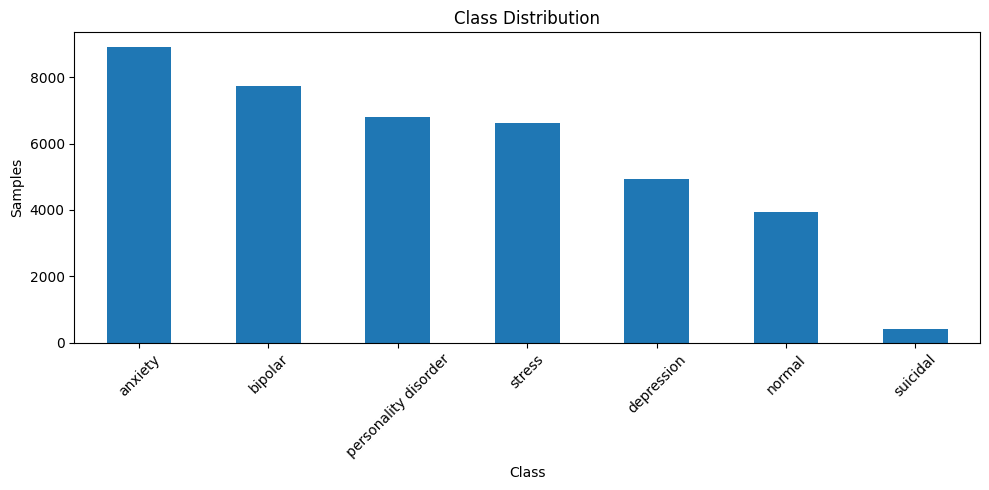

In [7]:
# Visualize class balance
df["status"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 3. Clean the dataset

Cleaning here is intentionally conservative. We remove invalid rows, normalize whitespace, remove exact duplicate texts, and keep the original meaning of the text.

We do **not** aggressively remove words such as "not", punctuation, or stopwords because they can carry important sentiment/meaning for transformer models.


In [8]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = df[["text", "status"]].copy()
df["text"] = df["text"].apply(clean_text)

# Remove empty/invalid examples
df = df[df["text"].str.len() >= 10]
df = df[df["status"].notna()]

# Remove exact duplicate text samples
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Cleaned shape:", df.shape)
display(df["status"].value_counts())
display(df.head())


Cleaned shape: (39316, 2)


,count
status,
anxiety,8901
bipolar,7726
personality disorder,6800
stress,6631
depression,4937
normal,3917
suicidal,404


,text,status
0,y huge knife is dull it never going to end is ...,depression
1,i wan na start by saying i feel like i have no...,depression
2,sometimes my life seems great and i tend to bl...,depression
3,i am currently a senior at a prestigious colle...,depression
4,i m tired of trying to be happy i m tired of s...,depression


## 4. Label encoding

In [9]:
labels = sorted(df["status"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

df["label"] = df["status"].map(label2id)

print("Labels:", labels)
print("label2id:", label2id)


Labels: ['anxiety', 'bipolar', 'depression', 'normal', 'personality disorder', 'stress', 'suicidal']
label2id: {'anxiety': 0, 'bipolar': 1, 'depression': 2, 'normal': 3, 'personality disorder': 4, 'stress': 5, 'suicidal': 6}


## 5. Train / validation / test split

A stratified split preserves the class proportions.

- 80% training
- 10% validation
- 10% test


In [10]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain distribution:")
display(train_df["status"].value_counts(normalize=True).sort_index())


Train: (31452, 3)
Validation: (3932, 3)
Test: (3932, 3)

Train distribution:


,proportion
status,
anxiety,0.226408
bipolar,0.196522
depression,0.125556
normal,0.099612
personality disorder,0.172962
stress,0.168670
suicidal,0.010270


## 6. Install/import Hugging Face tooling

Run the following in Google Colab or a GPU environment if needed.


In [11]:
# If running in a fresh Colab environment, uncomment:
!pip install -q transformers datasets evaluate accelerate scikit-learn

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
import evaluate


In [12]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_ds = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/31452 [00:00<?, ? examples/s]

Map:   0%|          | 0/3932 [00:00<?, ? examples/s]

Map:   0%|          | 0/3932 [00:00<?, ? examples/s]

In [13]:
import os
print(os.path.exists("/content/mindmirror_distilbert_model"))

False


## 7. Fine-tune DistilBERT

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_metric.compute(
            predictions=predictions,
            references=labels_true
        )["accuracy"],
        "f1_weighted": f1_metric.compute(
            predictions=predictions,
            references=labels_true,
            average="weighted"
        )["f1"],
        "precision_weighted": precision_metric.compute(
            predictions=predictions,
            references=labels_true,
            average="weighted"
        )["precision"],
        "recall_weighted": recall_metric.compute(
            predictions=predictions,
            references=labels_true,
            average="weighted"
        )["recall"]
    }


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
 # Reinstall transformers and accelerate to fix potential dependency issues
# After running this cell, please restart the Colab runtime (Runtime -> Restart runtime...)
!pip install --upgrade transformers accelerate

from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./mindmirror_checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    logging_steps=100,
    report_to="none",
    fp16=True  # use a GPU environment; set False if unsupported
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
1,0.210337,0.182633,0.942269,0.938208,0.935290,0.942269
2,0.116978,0.197774,0.945066,0.944005,0.944107,0.945066
3,0.085899,0.208743,0.944557,0.943731,0.943437,0.944557


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5898, training_loss=0.17073876552963385, metrics={'train_runtime': 621.378, 'train_samples_per_second': 151.85, 'train_steps_per_second': 9.492, 'total_flos': 5794831105960128.0, 'train_loss': 0.17073876552963385, 'epoch': 3.0})

In [20]:
import torch

print(torch.cuda.is_available())

True


## 8. Evaluate on the held-out test set

Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted,Precision Weighted,Recall Weighted
0.085899,0.194321,3,0.944303,0.944205,0.944631,0.944303


{'eval_loss': 0.19432121515274048, 'eval_accuracy': 0.9443031536113937, 'eval_f1_weighted': 0.9442053576427213, 'eval_precision_weighted': 0.9446305838089016, 'eval_recall_weighted': 0.9443031536113937}


                      precision    recall  f1-score   support

             anxiety     0.9463    0.9697    0.9578       890
             bipolar     0.9603    0.9379    0.9490       773
          depression     0.8610    0.9028    0.8814       494
              normal     0.9736    0.9413    0.9572       392
personality disorder     0.9524    0.9706    0.9614       680
              stress     0.9782    0.9472    0.9625       663
            suicidal     0.6667    0.5500    0.6027        40

            accuracy                         0.9443      3932
           macro avg     0.9055    0.8885    0.8960      3932
        weighted avg     0.9446    0.9443    0.9442      3932



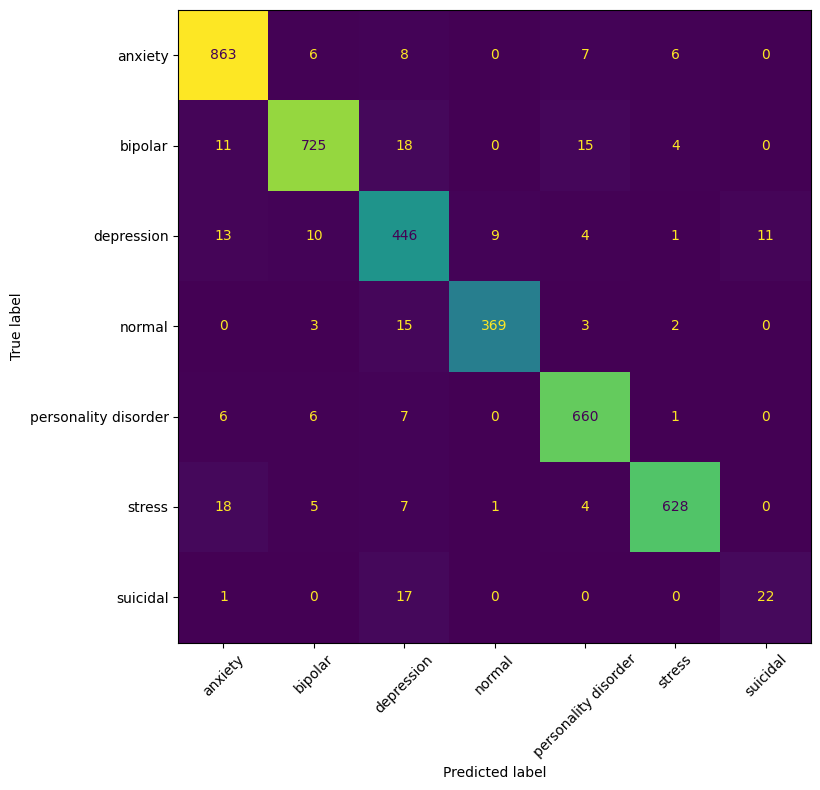

In [16]:
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)

pred_output = trainer.predict(test_ds)
test_predictions = np.argmax(pred_output.predictions, axis=-1)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(
    test_df["label"],
    test_predictions,
    target_names=labels,
    digits=4
))

cm = confusion_matrix(test_df["label"], test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(9, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()


## 9. Export the trained model

The exported directory is what the MindMirror backend can load or what can be uploaded to a Hugging Face model repository.

Do not commit API tokens to GitHub.


In [17]:
import json

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Save label mappings for the backend
with open(os.path.join(OUTPUT_DIR, "labels.json"), "w") as f:
    json.dump(
        {
            "label2id": label2id,
            "id2label": {str(k): v for k, v in id2label.items()}
        },
        f,
        indent=2
    )

print("Saved model to:", OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: mindmirror_distilbert_model


In [19]:
trainer.save_model(OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
trainer.save_model(OUTPUT_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 10. Test a single MindMirror-style journal entry

In [18]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=OUTPUT_DIR,
    tokenizer=OUTPUT_DIR,
    top_k=None
)

sample = "I have been feeling overwhelmed by college work and I am worried that I will fail."

result = classifier(sample)
display(result)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[[{'label': 'stress', 'score': 0.975395143032074},
  {'label': 'bipolar', 'score': 0.01089222077280283},
  {'label': 'anxiety', 'score': 0.007088791113346815},
  {'label': 'depression', 'score': 0.00301782856695354},
  {'label': 'normal', 'score': 0.001781458267942071},
  {'label': 'personality disorder', 'score': 0.0014062006957828999},
  {'label': 'suicidal', 'score': 0.0004183821438346058}]]

In [21]:
!zip -r mindmirror_distilbert_model.zip /content/mindmirror_distilbert_model

  adding: content/mindmirror_distilbert_model/ (stored 0%)
  adding: content/mindmirror_distilbert_model/training_args.bin (deflated 53%)
  adding: content/mindmirror_distilbert_model/model.safetensors (deflated 8%)
  adding: content/mindmirror_distilbert_model/labels.json (deflated 54%)
  adding: content/mindmirror_distilbert_model/config.json (deflated 53%)
  adding: content/mindmirror_distilbert_model/tokenizer_config.json (deflated 43%)
  adding: content/mindmirror_distilbert_model/tokenizer.json (deflated 71%)


In [22]:
from google.colab import files

files.download("/content/mindmirror_distilbert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Integration plan

After this notebook is validated:

1. Upload the trained model to Hugging Face Hub **or** package it for a dedicated ML service.
2. Add a backend `hfService.js` / `mlService.js` function that sends journal text to the model.
3. Keep the Hugging Face token on the backend only.
4. Call the model from the existing journal-analysis endpoint.
5. Store the classification/confidence as an additional analysis field.
6. Keep Gemini for contextual generation and suggestions.
7. Update the React analytics UI to display the model output as an informational signal.

Suggested API response:

```json
{
  "mlClassification": {
    "label": "stress",
    "confidence": 0.87
  },
  "geminiAnalysis": {
    "themes": [],
    "triggers": [],
    "copingSuggestions": []
  }
}
```

**Important:** The classifier must not be presented as diagnosing a mental-health condition. Use neutral wording such as *classification*, *detected language pattern*, or *risk-awareness signal*.
